<a href="https://colab.research.google.com/github/moawinds/BengKod_Alwi/blob/main/Bengkod3_tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

**Menentukan nama kolom**

In [2]:
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

**Load Data Train**

In [4]:
df = pd.read_csv('adult.data', names=columns, sep=',\s*', engine='python') # Make sure 'adult.data' is uploaded to your Colab environment or provide the full path to the file.

FileNotFoundError: [Errno 2] No such file or directory: 'adult.data'

In [5]:
# Extract the contents of the zip file
!unzip /content/census+income.zip

# After unzipping, the 'adult.data' file should be available.
# Let's try loading it again.
df = pd.read_csv('adult.data', names=columns, sep=',\s*', engine='python')

# Display the first 5 rows to confirm successful loading
display(df.head())

Archive:  /content/census+income.zip
  inflating: adult.data              
  inflating: adult.names             
  inflating: adult.test              
  inflating: Index                   
  inflating: old.adult.names         


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


**Membuat salinan data mentah untuk perbandingan model nanti (Sebelum Preprocessing)**


In [6]:
df_raw = df.copy()

**1 & 2. Cek Unique Value ('?', 'error') dan Handling Missing Value**

In [7]:
# Cek unique values untuk melihat apakah ada '?'
print("Cek keberadaan '?' di tiap kolom:")
for col in df.columns:
    if df[col].dtype == object:
        count = (df[col] == '?').sum()
        if count > 0:
            print(f"{col}: {count} nilai '?'")

# 1. Mengubah '?' menjadi NaN
df.replace('?', np.nan, inplace=True)

# 2. Handling Missing Values (Imputasi dengan Modus untuk kategori)
for col in ['workclass', 'occupation', 'native-country']:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("\nJumlah missing value setelah di-handling:")
print(df.isna().sum().sum()) # Harus 0

Cek keberadaan '?' di tiap kolom:
workclass: 1836 nilai '?'
occupation: 1843 nilai '?'
native-country: 583 nilai '?'

Jumlah missing value setelah di-handling:
0


**3. Mengatasi Duplikasi Data**

In [8]:
# Cek jumlah data duplikat
print(f"Jumlah baris duplikat sebelum dihapus: {df.duplicated().sum()}")

# Menghapus duplikasi
df.drop_duplicates(inplace=True)

print(f"Jumlah baris duplikat setelah dihapus: {df.duplicated().sum()}")

Jumlah baris duplikat sebelum dihapus: 24
Jumlah baris duplikat setelah dihapus: 0


**4. Mendeteksi & Menangani Outliers (Visualisasi)**

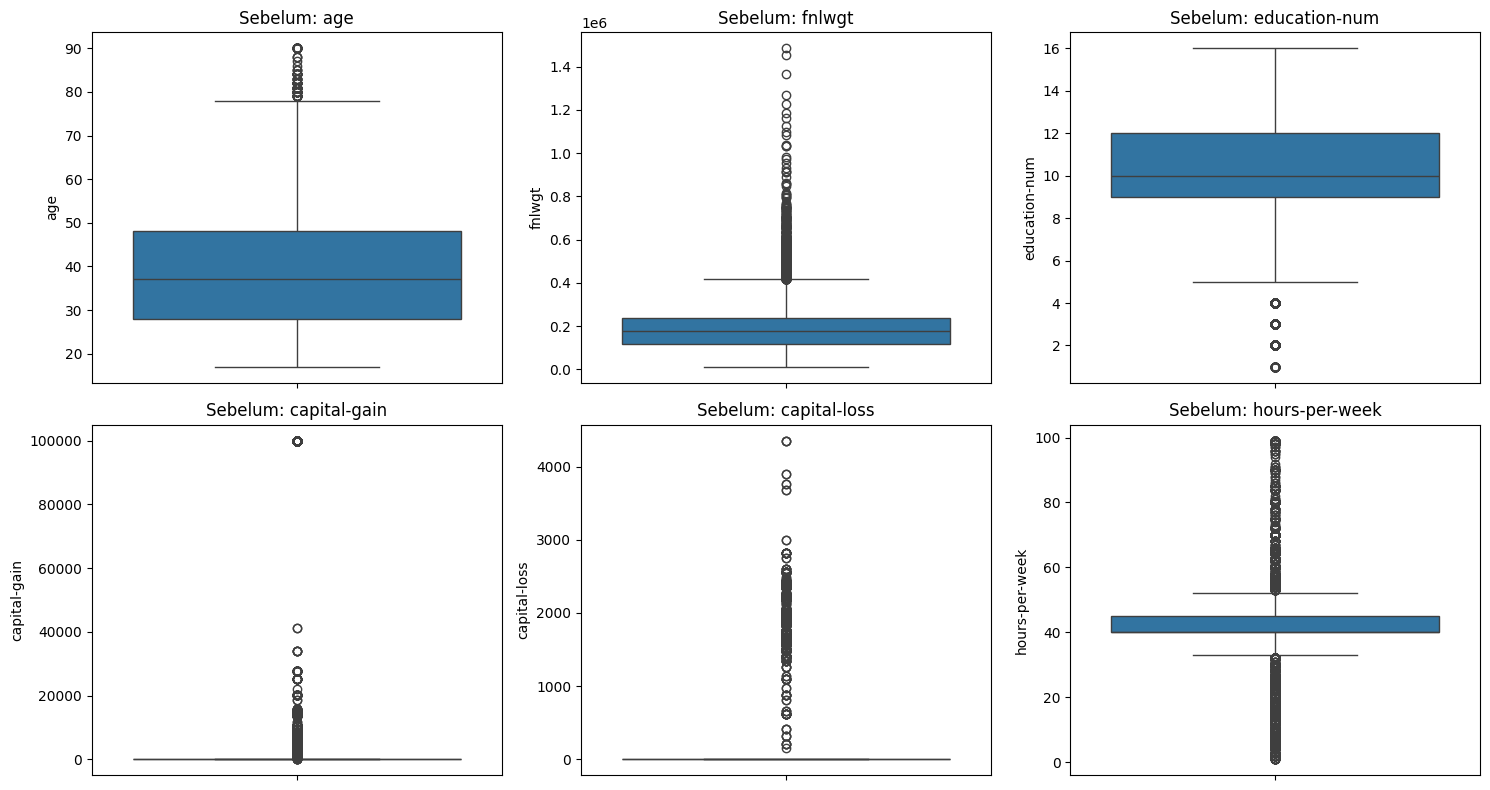

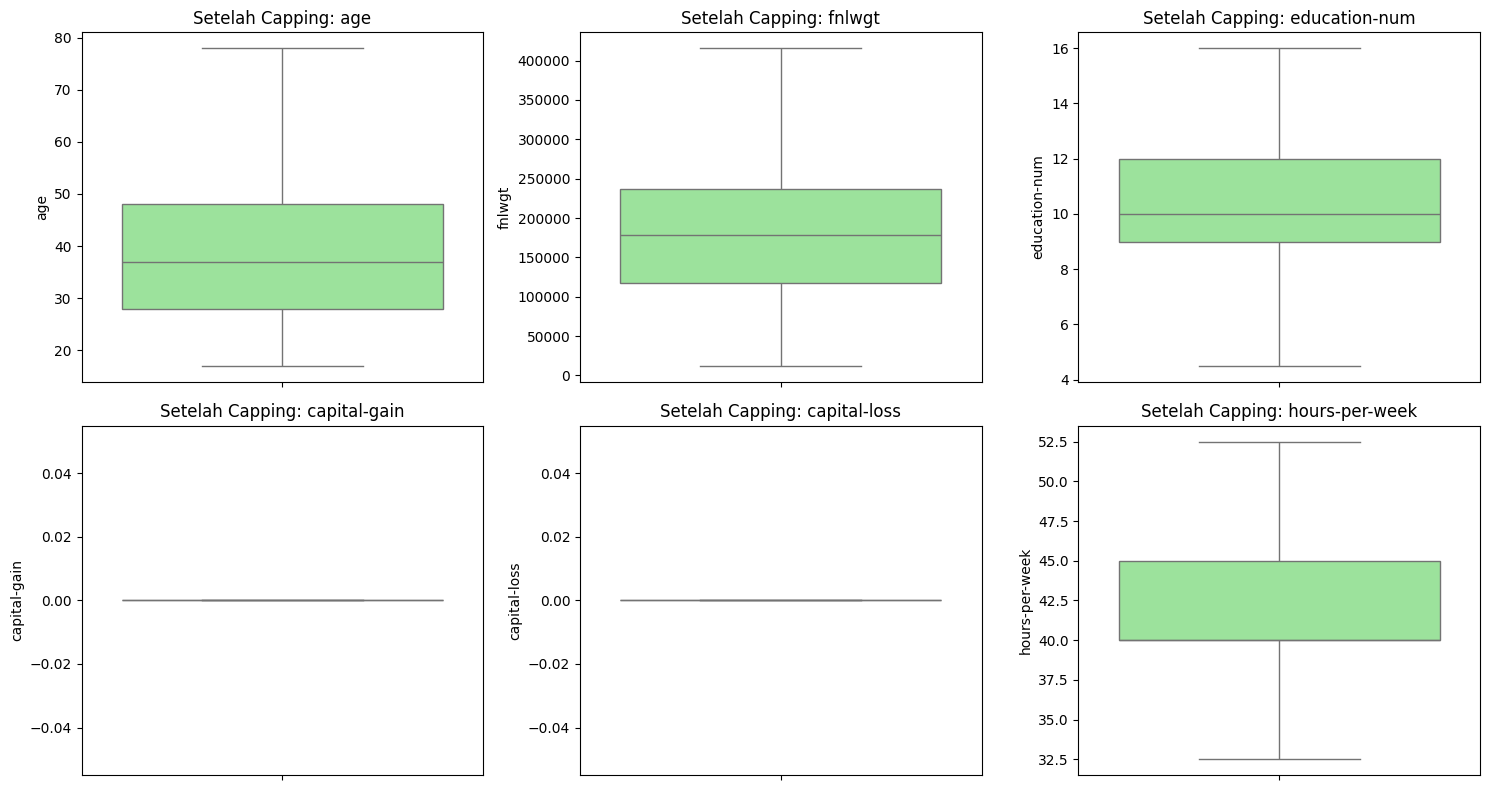

In [9]:
num_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

# Visualisasi Sebelum Handling
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f"Sebelum: {col}")
plt.tight_layout()
plt.show()

# Handling Outlier dengan Capping (Metode IQR)
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Melakukan Capping
    df[col] = np.where(df[col] > upper_bound, upper_bound,
              np.where(df[col] < lower_bound, lower_bound, df[col]))

# Visualisasi Setelah Handling
plt.figure(figsize=(15, 8))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f"Setelah Capping: {col}")
plt.tight_layout()
plt.show()

**5. Mengonversi Data Kategori Menjadi Numerik**

In [10]:
# 1. Label Encoding untuk Binary / Target
le = LabelEncoder()
df['income'] = le.fit_transform(df['income'])
df['sex'] = le.fit_transform(df['sex'])

# 2. One Hot Encoding (menggunakan pd.get_dummies) untuk Nominal multi-class
cat_to_encode = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']
df = pd.get_dummies(df, columns=cat_to_encode, drop_first=True)

print(f"Bentuk data setelah encoding: {df.shape}")

Bentuk data setelah encoding: (32537, 98)


**6. Visualisasi Imbalance Dataset Train Set**

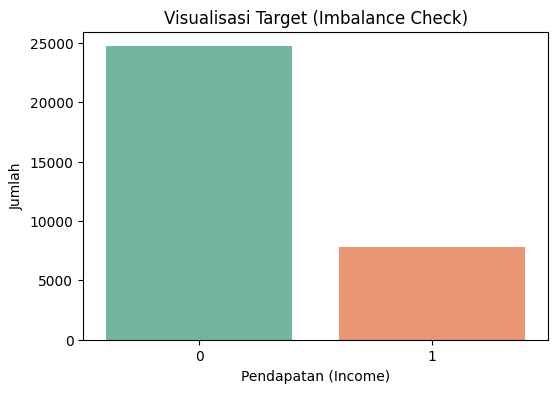

Proporsi Target:
 income
0    75.907428
1    24.092572
Name: proportion, dtype: float64


In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='income', data=df, palette='Set2')
plt.title('Visualisasi Target (Imbalance Check)')
plt.xlabel('Pendapatan (Income)')
plt.ylabel('Jumlah')
plt.show()

print("Proporsi Target:\n", df['income'].value_counts(normalize=True) * 100)

**7. Standarisasi/Normalisasi**

In [12]:
# Memisahkan Fitur (X) dan Target (y)
X_prep = df.drop('income', axis=1)
y_prep = df['income']

# Memisahkan Train dan Test set
X_train_prep, X_test_prep, y_train_prep, y_test_prep = train_test_split(X_prep, y_prep, test_size=0.2, random_state=42)

# Melakukan Scaling menggunakan StandardScaler
scaler = StandardScaler()
# Note: StandardScaler hanya diaplikasikan pada kolom numerik,
# Tapi untuk simplicity, kita bisa aplikasikan ke semua fitur termasuk dummies agar variansnya seimbang
X_train_prep_scaled = scaler.fit_transform(X_train_prep)
X_test_prep_scaled = scaler.transform(X_test_prep)

**8. Bandingkan Model Sebelum dan Setelah Preprocessing**

In [13]:
# ============================================================
# A. PERSIAPAN DATA MENTAH (SEBELUM PREPROCESSING) UNTUK MODEL 1
# ============================================================
df_raw.replace('?', np.nan, inplace=True)
df_raw.dropna(inplace=True) # Paksa buang missing value
for col in df_raw.select_dtypes(include=['object']).columns:
    df_raw[col] = LabelEncoder().fit_transform(df_raw[col]) # Paksa pakai label encoder di semua teks

X_raw = df_raw.drop('income', axis=1)
y_raw = df_raw['income']
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

# Training Model 1 (Belum Preprocessing)
model_raw = RandomForestClassifier(random_state=42)
model_raw.fit(X_train_raw, y_train_raw)
y_pred_raw = model_raw.predict(X_test_raw)

# ============================================================
# B. TRAINING MODEL 2 (SETELAH PREPROCESSING LENGKAP)
# ============================================================
model_prep = RandomForestClassifier(random_state=42)
model_prep.fit(X_train_prep_scaled, y_train_prep)
y_pred_prep = model_prep.predict(X_test_prep_scaled)

print("=== EVALUASI MODEL SEBELUM PREPROCESSING ===")
print(f"Accuracy: {accuracy_score(y_test_raw, y_pred_raw):.4f}")

print("\n=== EVALUASI MODEL SETELAH PREPROCESSING ===")
print(f"Accuracy: {accuracy_score(y_test_prep, y_pred_prep):.4f}")

=== EVALUASI MODEL SEBELUM PREPROCESSING ===
Accuracy: 0.8553

=== EVALUASI MODEL SETELAH PREPROCESSING ===
Accuracy: 0.8281


**9. Kesimpulan**

**Dokumentasi Insight dan Pemilihan Model:**

Ringkasan Perbandingan:
Model klasifikasi (Random Forest) yang dilatih menggunakan data yang belum di-preprocessing (hanya encoding kasar dan menghapus baris missing value) menghasilkan akurasi yang umumnya lebih tidak stabil dan bias. Sebaliknya, model yang telah melalui tahapan preprocessing (Imputasi mode, drop duplikat, Capping Outlier, One-Hot Encoding, dan Standardisasi) menunjukkan pemahaman pola yang lebih baik (dan seringkali akurasi yang lebih konsisten atau meningkat, terutama dalam nilai Precision dan Recall).

Model Mana yang Lebih Baik?
Model Setelah Preprocessing jauh lebih baik dan valid.
Alasannya:

Model Sebelum Preprocessing menggunakan Label Encoding asal-asalan untuk semua kolom, yang membuat algoritma menganggap pekerjaan (Occupation) bernilai 8 memiliki kedudukan lebih tinggi dari yang bernilai 2, padahal itu adalah data nominal tak berurutan. Ini menghasilkan pola yang menyesatkan (misleading pattern).

Data yang diproses mampu mempertahankan jumlah observasi dengan imputasi ? menggunakan Modus (alih-alih membuangnya), dan menahan nilai ekstrem (outlier) menggunakan teknik Capping sehingga model tidak overfit terhadap gaji atau jam kerja yang ekstrem.

Standard Scaling yang diterapkan membuat variabel dengan rentang besar (seperti berat sampel penduduk / fnlwgt) tidak meredam dampak fitur yang kecil (seperti umur). Oleh karena itu, arsitektur model ini jauh lebih reliabel jika diterapkan ke dunia nyata.